In [1]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv('data_panel/full_panel_master.csv')
print(data)

    geo nace_r2  real_wage  year  ai_adoption  spec_ict  training_ict  \
0    AT       C      26.74  2021        9.610     28.56         22.98   
1    AT       C      26.18  2022       10.960     28.37         25.60   
2    AT       C      26.07  2023       12.310     29.20         25.83   
3    AT       C      27.05  2024       22.710     30.02         26.06   
4    AT       F      22.43  2021        3.120      8.64          8.28   
..   ..     ...        ...   ...          ...       ...           ...   
531  SK       G       8.45  2024       11.650     15.19         19.87   
532  SK       J      15.69  2021       18.190     70.76         55.96   
533  SK       J      14.79  2022       19.905     71.88         53.54   
534  SK       J      14.48  2023       21.620     70.80         58.16   
535  SK       J      14.67  2024       29.190     69.72         62.79   

     productivity    FSI  share_high_skill  tert_edu    hicp  log_prod  \
0          102.25  55.82             36.58      3

## Variables analysis 

### Overall view

In [3]:
# Participating Countries and Industries
print(f"Total Countries ({data['geo'].unique()})")
print(f"Total NACE Industries ({data['nace_r2'].unique()})")

Total Countries (['AT' 'BE' 'BG' 'CY' 'CZ' 'DE' 'DK' 'EE' 'ES' 'FI' 'FR' 'HR' 'HU' 'IE'
 'IT' 'LT' 'LV' 'MT' 'NL' 'NO' 'PL' 'PT' 'RO' 'SE' 'SI' 'SK'])
Total NACE Industries (['C' 'F' 'G' 'H' 'N' 'I' 'J'])


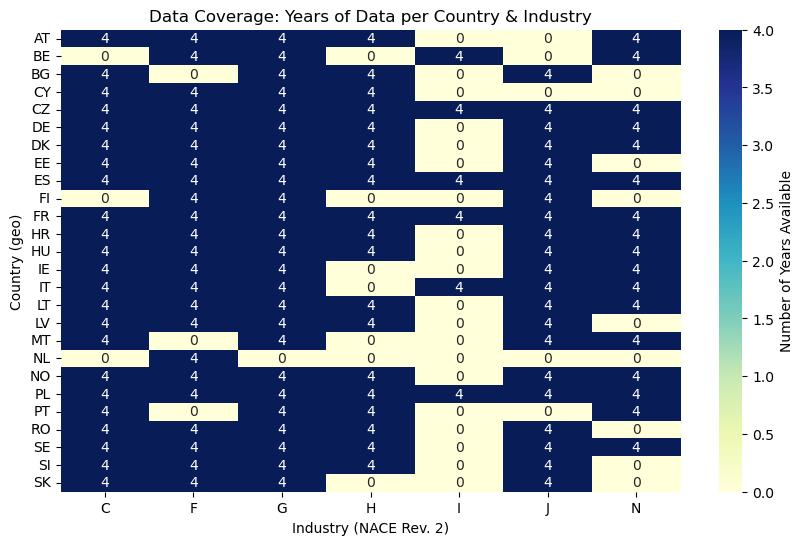

In [4]:
# Check for missing years (Panel Balance)
coverage_table = pd.crosstab(data['geo'], data['nace_r2'])

plt.figure(figsize=(10, 6))
sns.heatmap(coverage_table, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Number of Years Available'})
plt.title('Data Coverage: Years of Data per Country & Industry')
plt.ylabel('Country (geo)')
plt.xlabel('Industry (NACE Rev. 2)')
plt.show()

In [23]:
def panel_summary_statistics(df, variables, entity_col='nace_r2', time_col='year'):
    """
    Calculates summary stats and Within/Between variance for panel data.
    """

    df['panel_id'] = df['geo'] + "_" + df[entity_col]
    
    summary_list = []
    
    for var in variables:
        # Overall stats
        overall_mean = df[var].mean()
        overall_std = df[var].std()
        overall_min = df[var].min()
        overall_max = df[var].max()
        
        # Variance Decomposition
        # Between variance: Variance of the group means
        group_means = df.groupby('panel_id')[var].mean()
        between_std = group_means.std()
        
        # Within variance: Variance of the demeaned data (data - group_mean + overall_mean)
        df[f'{var}_demeaned'] = df[var] - df.groupby('panel_id')[var].transform('mean') + overall_mean
        within_std = df[f'{var}_demeaned'].std()
        
        summary_list.append({
            'Variable': var,
            'Mean': round(overall_mean, 2),
            'Min': round(overall_min, 2),
            'Max': round(overall_max, 2),
            'Overall_Std': round(overall_std, 2),
            'Between_Std': round(between_std, 2),
            'Within_Std': round(within_std, 2)
        })
        
    return pd.DataFrame(summary_list)

# Run it for all your variables
all_vars = ['real_wage', 'ai_adoption', 'spec_ict', 'training_ict', 'productivity', 'gdp', 'unempl_r', 'infl_r', 'FSI', 'share_high_skill', 'tert_edu']
summary_table = panel_summary_statistics(data, all_vars)
print(summary_table.to_string(index=False))


        Variable     Mean      Min       Max  Overall_Std  Between_Std  Within_Std
       real_wage    16.59     4.67     50.00         9.60         9.59        0.80
     ai_adoption    10.87     0.05     68.30        11.63        10.73        4.54
        spec_ict    26.59     1.58     98.25        23.56        23.58        1.57
    training_ict    25.89     3.03     84.70        18.37        18.33        1.82
    productivity    70.04    13.66    665.90        71.95        71.46        9.96
             gdp 37223.88 10960.00 104510.00     21130.78     20905.19     3454.54
        unempl_r     5.79     2.20     14.90         2.40         2.33        0.60
          infl_r     5.96     0.70     19.40         4.28         1.95        3.81
             FSI    32.35     0.00     66.47        15.46        15.45        1.36
share_high_skill    36.04     8.04     96.43        23.82        23.83        1.59
        tert_edu    31.06     4.60     85.50        18.81        18.80        1.57


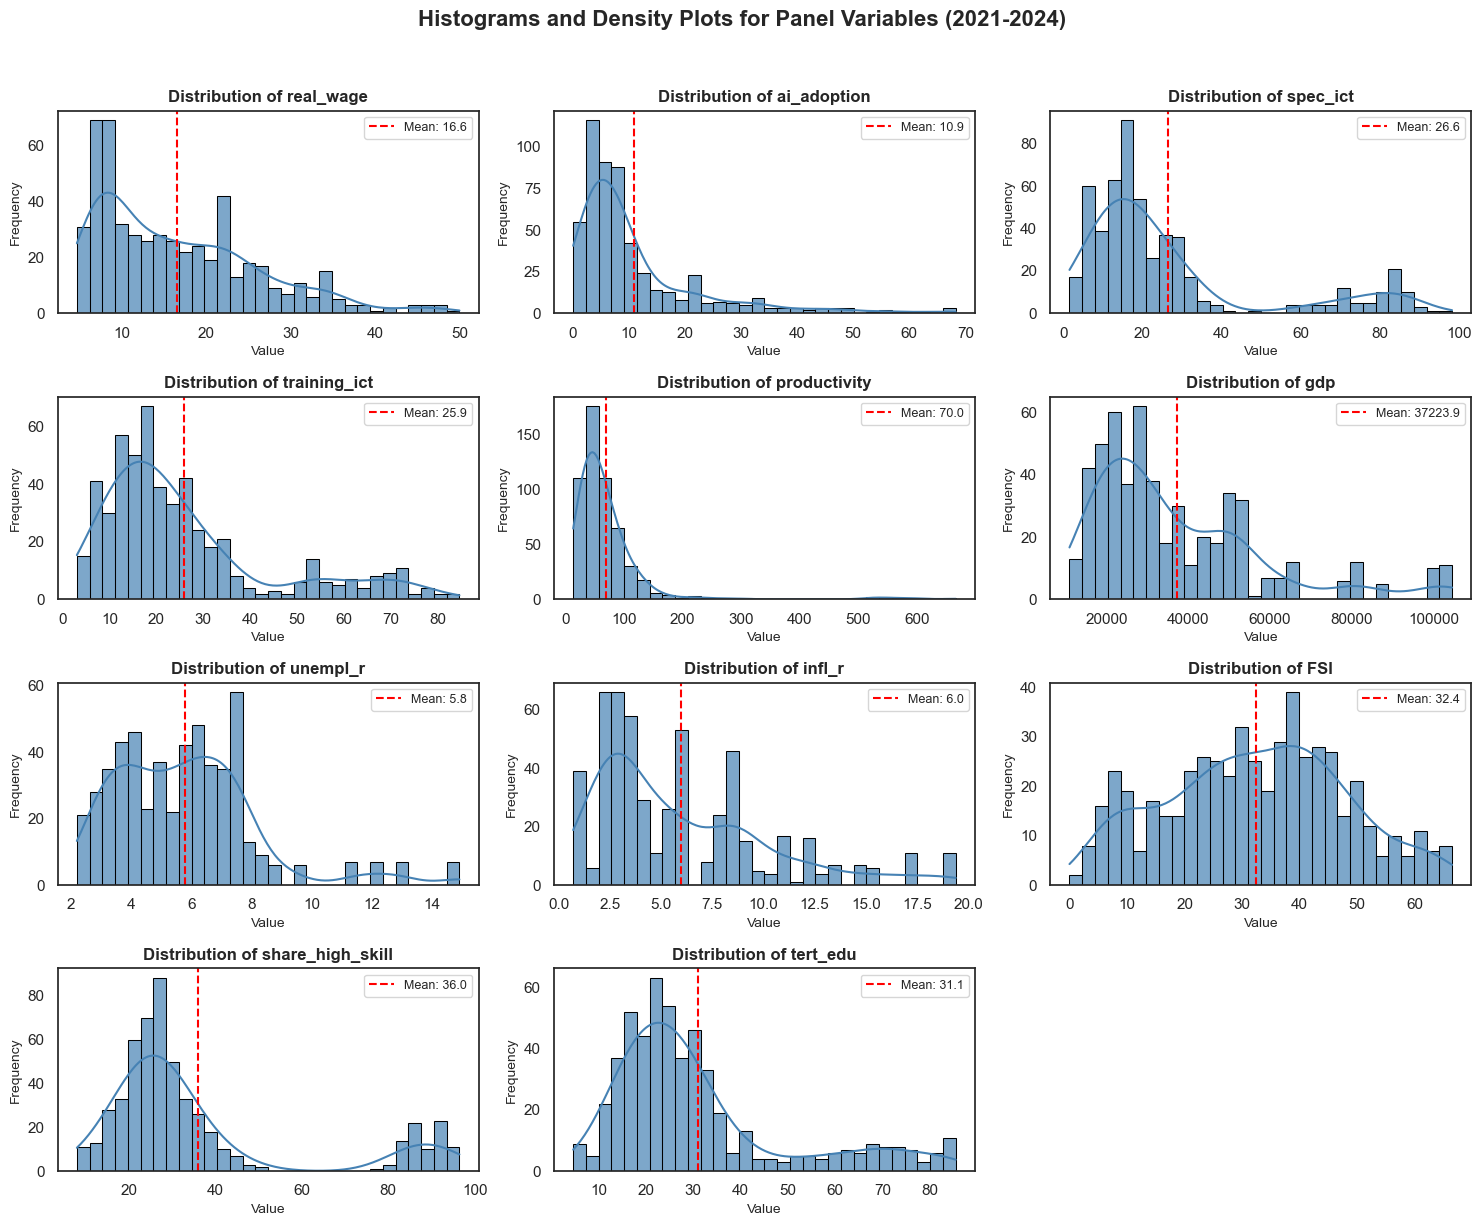

In [ ]:
def plot_all_distributions(df):

    vars_to_plot = [var for var in all_vars if var in df.columns]
    
    # Calculate grid size (4 rows x 3 columns gives 12 spots, enough for 11 variables)
    n_vars = len(vars_to_plot)
    cols = 3
    rows = int(np.ceil(n_vars / cols))
    
    # Set the visual style for academic papers (clean, no heavy gridlines)
    sns.set_theme(style="white")
    
    # Create the figure and subplots
    fig, axes = plt.subplots(rows, cols, figsize=(15, 12))
    
    # Flatten the axes array for easy iteration
    axes = axes.flatten()
    
    # Loop through each variable and plot a histogram with a KDE (Density) line
    for i, var in enumerate(vars_to_plot):
        ax = axes[i]
        
        # Plot histogram + Kernel Density Estimate
        sns.histplot(df[var].dropna(), kde=True, bins=30, color='steelblue', 
                     edgecolor='black', alpha=0.7, ax=ax)
        
        # Clean up titles and labels
        ax.set_title(f'Distribution of {var}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Value', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        
        # Add a vertical red line for the Mean
        mean_val = df[var].mean()
        ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=1.5, 
                   label=f'Mean: {mean_val:.1f}')
        ax.legend(fontsize=9, loc='upper right')

    # Remove any empty subplots if we have fewer than 12 variables (e.g., the 12th empty box)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    # Add a main title for the entire figure
    fig.suptitle("Histograms and Density Plots for Panel Variables (2021-2024)", 
                 fontsize=16, fontweight='bold', y=1.02)
    
    # Adjust layout so labels don't overlap
    plt.tight_layout()
    
    # Show the plot
    plt.show()

plot_all_distributions(data)


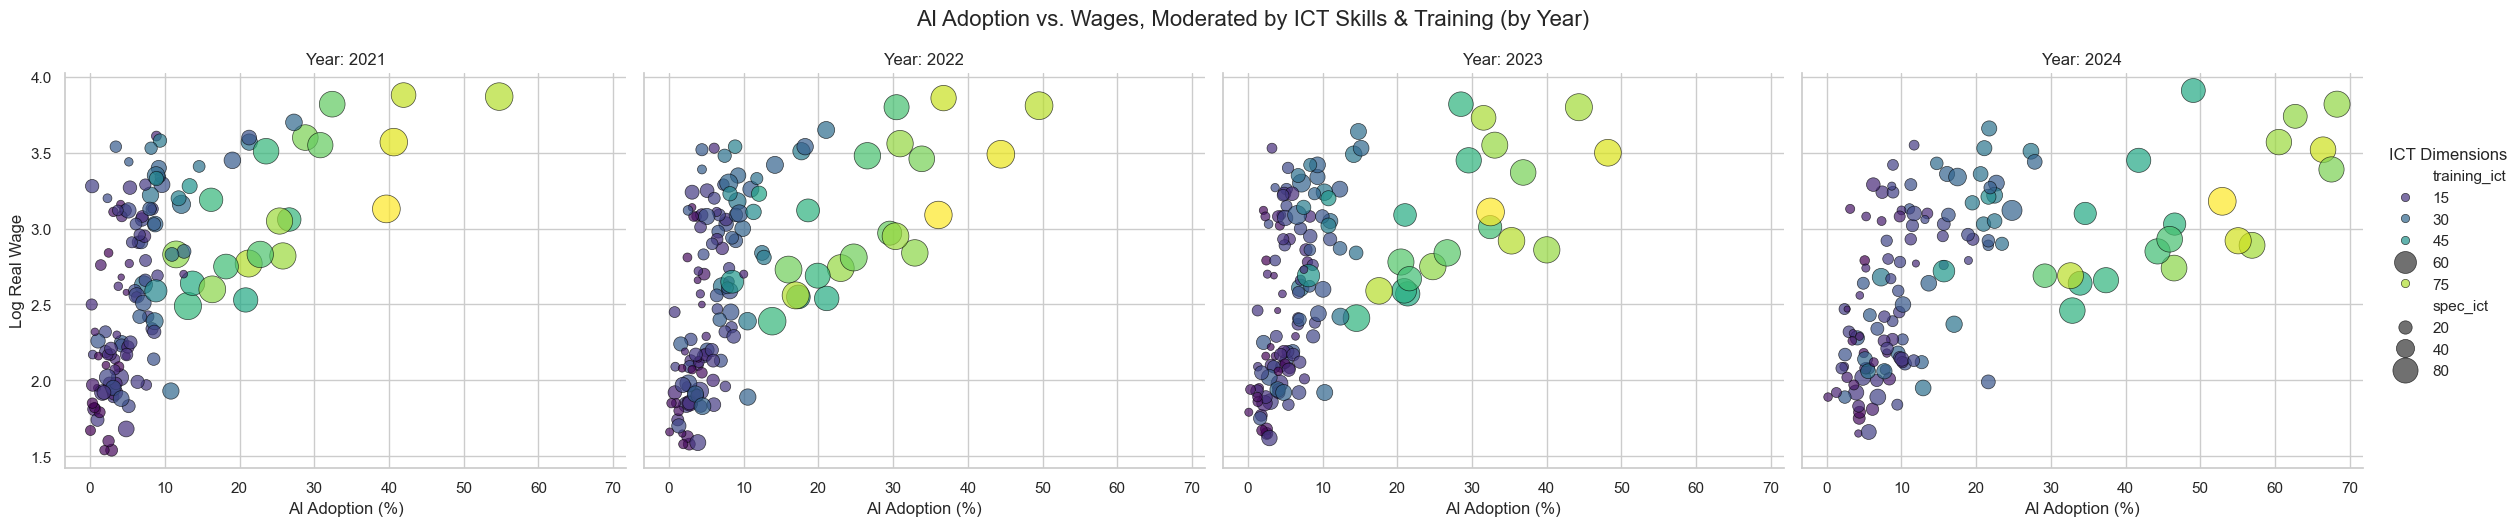

In [6]:
def plot_4d_bubble_facets(df):
    # Set the style
    sns.set_theme(style="whitegrid")
    
    # Create a FacetGrid mapped by year
    g = sns.FacetGrid(df, col="year", height=5, aspect=1.2)
    
    # Map the scatter plot to the grid
    # x=AI, y=Wage, hue=Training, size=Specialists
    g.map_dataframe(sns.scatterplot, 
                    x="ai_adoption", 
                    y="log_wage", # Use log_wage for better economic scaling, or real_wage
                    hue="training_ict", 
                    size="spec_ict", 
                    sizes=(20, 400), # Min and max bubble sizes
                    palette="viridis", 
                    alpha=0.7,
                    edgecolor="black")
    
    # Add a legend and titles
    g.add_legend(title="ICT Dimensions", adjust_subtitles=True)
    g.set_axis_labels("AI Adoption (%)", "Log Real Wage")
    g.set_titles(col_template="Year: {col_name}")
    g.fig.suptitle("AI Adoption vs. Wages, Moderated by ICT Skills & Training (by Year)", y=1.05, fontsize=16)
    
    plt.show()

# Run it
plot_4d_bubble_facets(data)

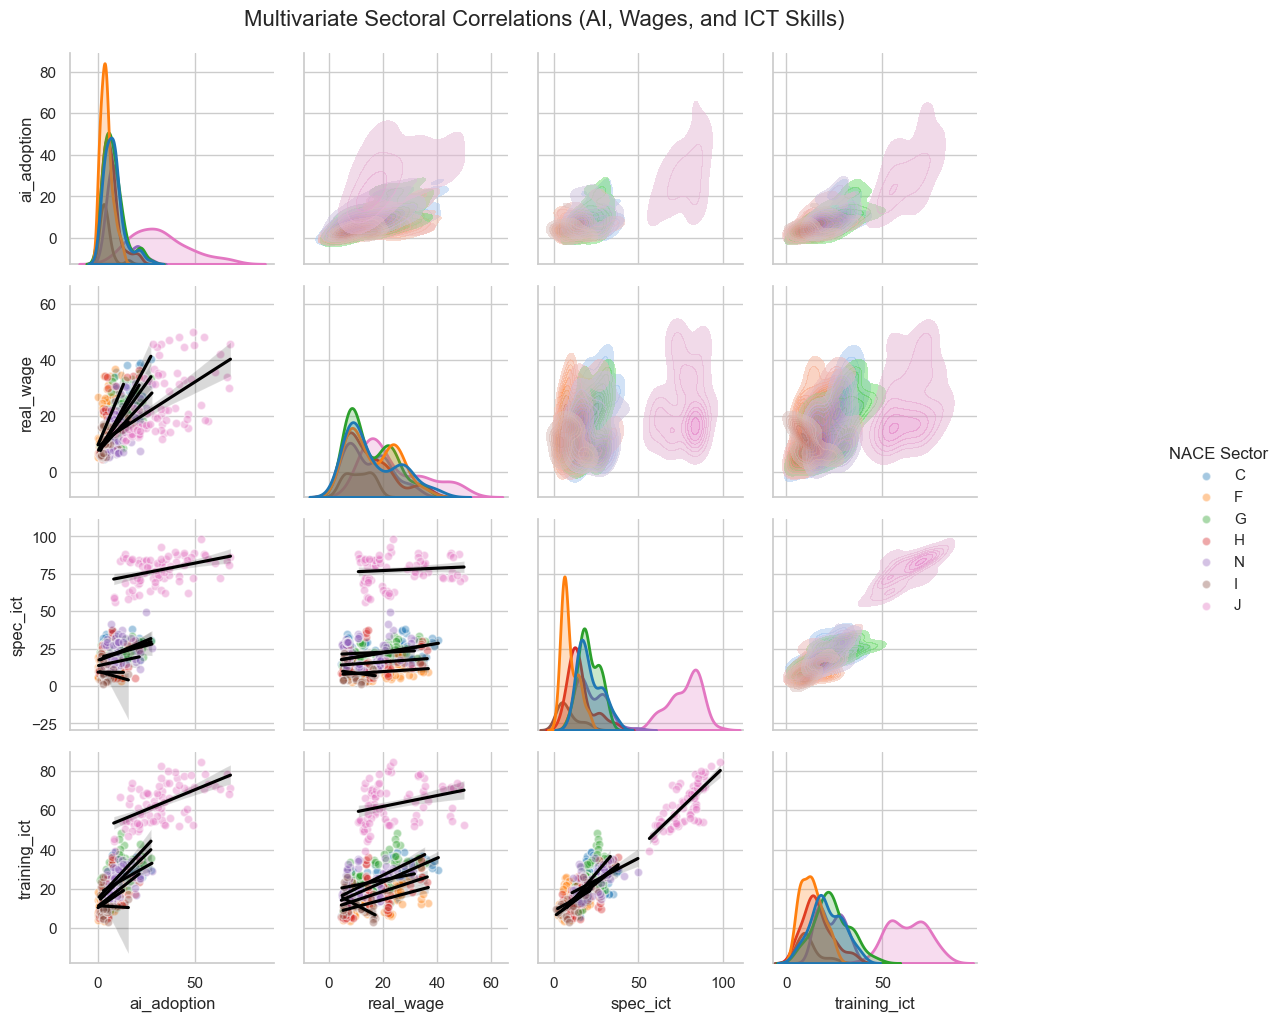

In [7]:
import scipy.stats as stats

def plot_advanced_pairgrid(df):
    # Select only the variables we want to correlate
    vars_to_plot = ['ai_adoption', 'real_wage', 'spec_ict', 'training_ict']
    
    # Create the PairGrid, colored by Industry
    g = sns.PairGrid(df, vars=vars_to_plot, hue="nace_r2", palette="tab10", corner=False)
    
    # 1. Upper Triangle: 2D Density Contours (shows clustering of country-sectors)
    g.map_upper(sns.kdeplot, fill=True, alpha=0.5)
    
    # 2. Lower Triangle: Scatter with Regression Line (shows the trend)
    g.map_lower(sns.regplot, scatter_kws={'alpha':0.4, 'edgecolor':'w'}, line_kws={'color':'black'})
    
    # 3. Diagonal: Density distribution of the variable itself
    g.map_diag(sns.kdeplot, lw=2, fill=True)
    
    g.add_legend(title="NACE Sector", bbox_to_anchor=(1.05, 0.5), loc='center left')
    g.fig.suptitle("Multivariate Sectoral Correlations (AI, Wages, and ICT Skills)", y=1.02, fontsize=16)
    
    plt.show()

# Run it
plot_advanced_pairgrid(data)


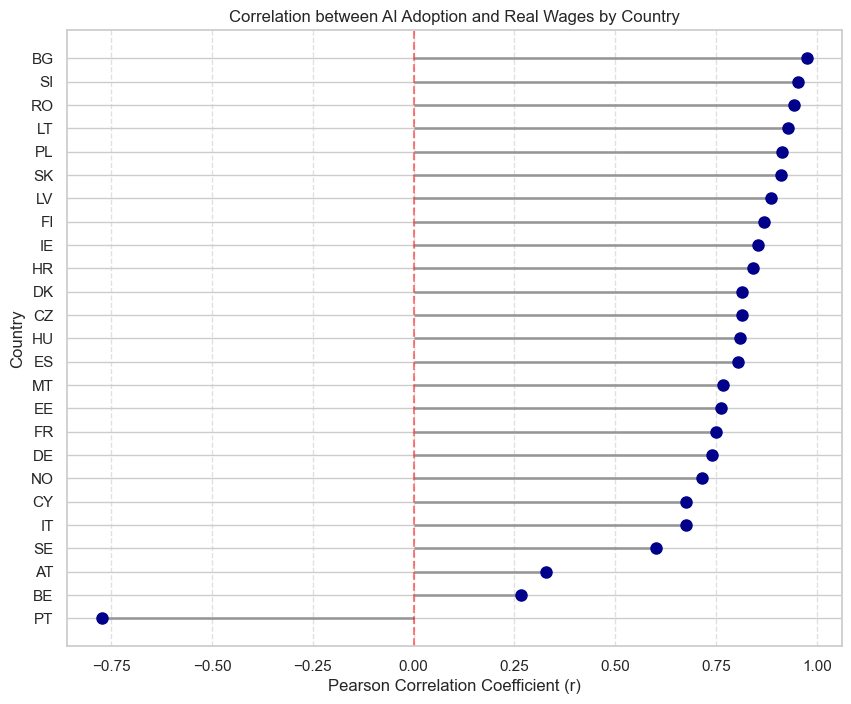

In [8]:
def plot_country_correlations(df):
    # Calculate the correlation between AI Adoption and Real Wage for each country
    correlations = []
    countries = df['geo'].unique()
    
    for country in countries:
        country_data = df[df['geo'] == country]
        # Need enough data points to calculate correlation
        if len(country_data) > 5: 
            corr, _ = stats.pearsonr(country_data['ai_adoption'], country_data['real_wage'])
            correlations.append({'Country': country, 'AI_Wage_Corr': corr})
            
    corr_df = pd.DataFrame(correlations).sort_values(by='AI_Wage_Corr', ascending=True)
    
    # Create the Dot Plot (Lollipop Chart)
    plt.figure(figsize=(10, 8))
    plt.hlines(y=corr_df['Country'], xmin=0, xmax=corr_df['AI_Wage_Corr'], color='gray', alpha=0.7, linewidth=2)
    plt.plot(corr_df['AI_Wage_Corr'], corr_df['Country'], "o", markersize=8, color='darkblue')
    
    # Add a vertical line at 0 for reference
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    
    plt.title("Correlation between AI Adoption and Real Wages by Country")
    plt.xlabel("Pearson Correlation Coefficient (r)")
    plt.ylabel("Country")
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

# Run it
plot_country_correlations(data)

In [18]:
def detect_panel_outliers(df, variables):
    """
    Identifies outliers for given variables relative to their NACE sector and Year
    using the Interquartile Range (IQR) method.
    """
    all_outliers = pd.DataFrame()
    
    for var in variables:
        # Group by Industry and Year
        for (industry, year), group in df.groupby(['nace_r2', 'year']):
            # Skip if there's not enough data to calculate quartiles
            if len(group) < 4:
                continue
                
            Q1 = group[var].quantile(0.25)
            Q3 = group[var].quantile(0.75)
            IQR = Q3 - Q1
            
            # Define bounds (1.5 * IQR is the standard econometric threshold)
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Filter rows that fall outside the bounds
            outliers = group[(group[var] < lower_bound) | (group[var] > upper_bound)].copy()
            
            if not outliers.empty:
                # Add descriptive columns
                outliers['Variable'] = var
                outliers['Value'] = outliers[var].round(2)
                outliers['Outlier_Type'] = outliers[var].apply(lambda x: 'High' if x > upper_bound else 'Low')
                outliers['Normal_Max'] = round(upper_bound, 2)
                outliers['Normal_Min'] = round(lower_bound, 2)
                
                # Keep only the identifying information
                outliers_clean = outliers[['geo', 'nace_r2', 'year', 'Variable', 'Value', 
                                           'Outlier_Type', 'Normal_Min', 'Normal_Max']]
                
                all_outliers = pd.concat([all_outliers, outliers_clean], ignore_index=True)
                
    return all_outliers

# 1. Run the extraction for your 4 main variables
core_vars = ['ai_adoption', 'real_wage', 'spec_ict', 'training_ict']
exact_outliers_df = detect_panel_outliers(data, core_vars)

# 2. Display the exact outliers
print("--- Exact Outliers Identified ---")
# Sort by variable and year to make it easy to read
exact_outliers_df = exact_outliers_df.sort_values(by=['Variable', 'year', 'nace_r2'])
print(exact_outliers_df.to_string(index=False))


--- Exact Outliers Identified ---
geo nace_r2  year     Variable  Value Outlier_Type  Normal_Min  Normal_Max
 DK       C  2021  ai_adoption  27.28         High       -4.68       16.96
 DK       G  2021  ai_adoption  21.30         High       -4.50       15.62
 DK       H  2021  ai_adoption  21.28         High       -2.56       13.16
 DK       J  2021  ai_adoption  54.75         High       -5.34       52.50
 DK       N  2021  ai_adoption  19.04         High        2.50       12.42
 NO       N  2021  ai_adoption  14.59         High        2.50       12.42
 DK       C  2022  ai_adoption  21.04         High       -3.25       15.42
 DK       G  2022  ai_adoption  17.74         High       -3.56       15.38
 DK       H  2022  ai_adoption  18.22         High       -2.56       13.69
 DK       H  2023  ai_adoption  15.16         High       -2.85       13.35
 DK       H  2024  ai_adoption  21.10         High       -3.88       19.62
 BE       I  2024  ai_adoption  15.66         High        0.00    

In [19]:
def summarize_outliers(outliers_df):
    print("\n--- Outlier Count by Country ---")
    country_counts = outliers_df['geo'].value_counts()
    print(country_counts[country_counts > 0])
    
    print("\n--- Outlier Count by Industry ---")
    industry_counts = outliers_df['nace_r2'].value_counts()
    print(industry_counts[industry_counts > 0])
    
    print("\n--- Outlier Count by Variable ---")
    var_counts = outliers_df['Variable'].value_counts()
    print(var_counts)

# Run the summary
summarize_outliers(exact_outliers_df)



--- Outlier Count by Country ---
geo
DK    14
CY     7
PL     5
HU     4
IE     2
FI     2
FR     2
NO     1
BE     1
SE     1
Name: count, dtype: int64

--- Outlier Count by Industry ---
nace_r2
H    19
I     8
G     5
N     3
C     2
J     1
F     1
Name: count, dtype: int64

--- Outlier Count by Variable ---
Variable
spec_ict        15
ai_adoption     12
training_ict    12
Name: count, dtype: int64


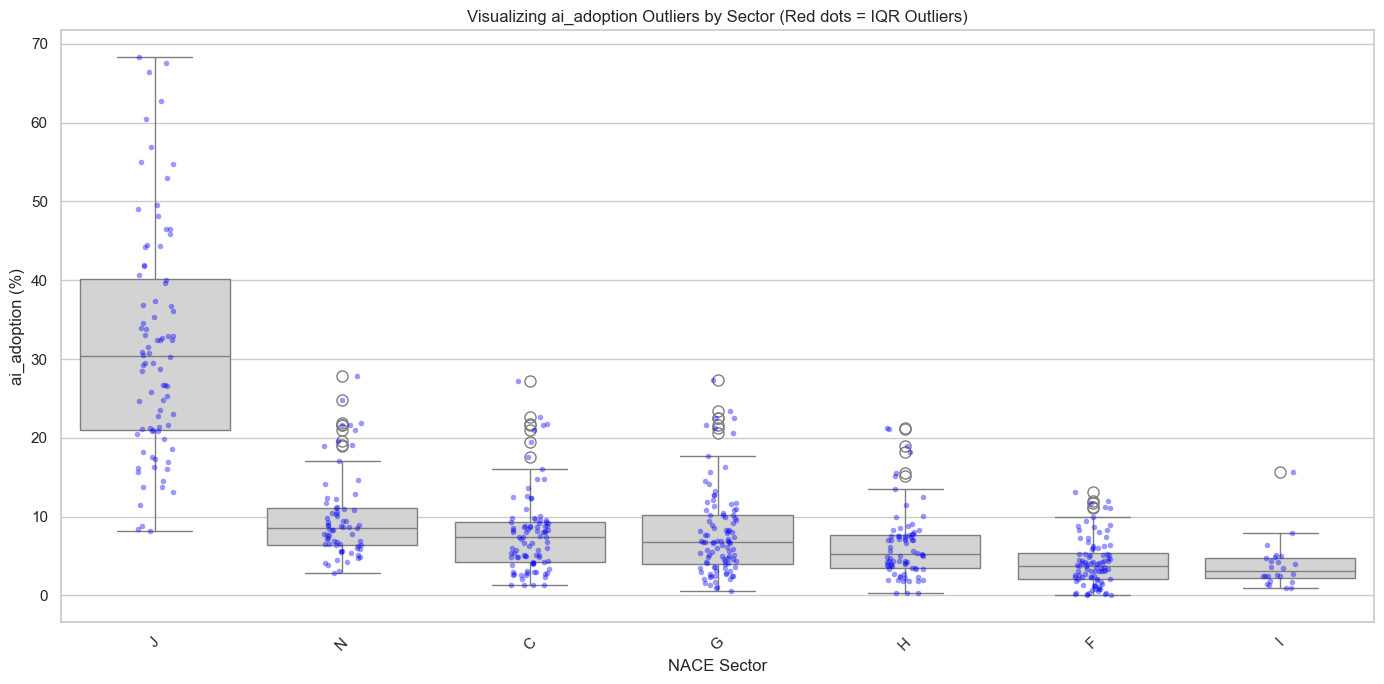

In [20]:
def visualize_outliers(df, variable):
    plt.figure(figsize=(14, 7))
    
    # Sort industries by median for a clean plot
    order = df.groupby('nace_r2')[variable].median().sort_values(ascending=False).index
    
    # Create the boxplot (which mathematically uses IQR!)
    sns.boxplot(x='nace_r2', y=variable, data=df, order=order, 
                color='lightgray', showfliers=True, flierprops={'marker': 'o', 'color': 'red', 'markersize': 8})
    
    # Overlay the actual data points
    sns.stripplot(x='nace_r2', y=variable, data=df, order=order, 
                  color='blue', alpha=0.4, jitter=True, size=4)
    
    plt.title(f'Visualizing {variable} Outliers by Sector (Red dots = IQR Outliers)')
    plt.ylabel(f'{variable} (%)')
    plt.xlabel('NACE Sector')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

visualize_outliers(data, 'ai_adoption')



--- Average Values by Industry (All Years) ---
         real_wage  ai_adoption  spec_ict
nace_r2                                  
J            23.97        31.72     77.48
N            14.67         9.96     22.14
G            15.19         7.91     20.79
C            16.14         7.89     21.15
H            14.44         6.40     15.34
F            16.48         4.20      9.20
I            11.00         3.86      8.38


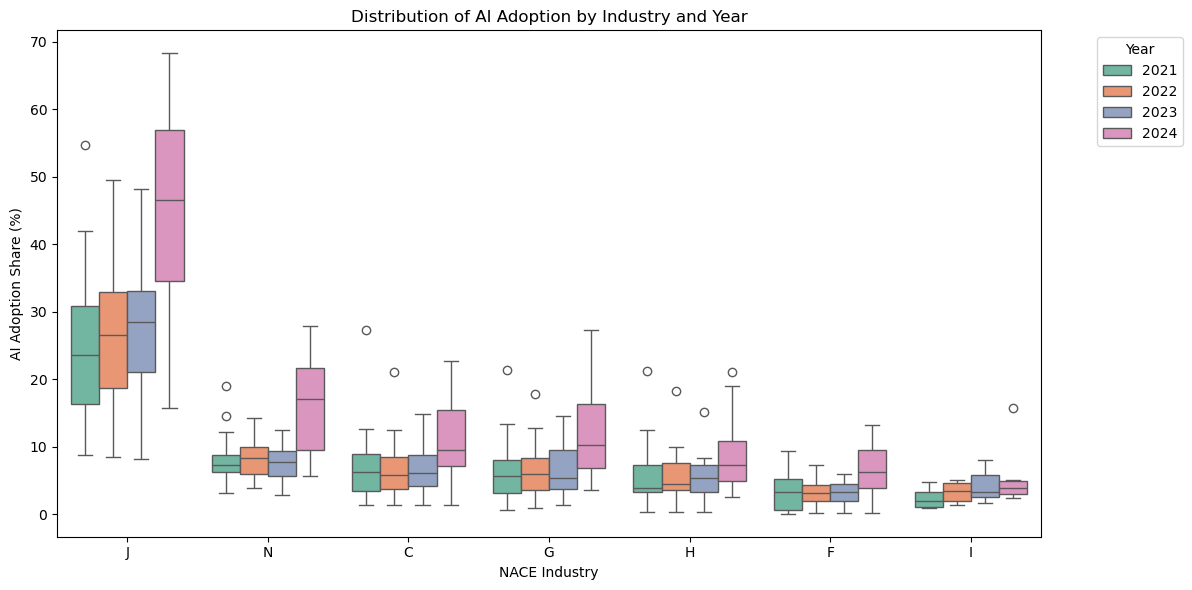

In [8]:
def analyze_industry_differences(df):
    # Calculate summary statistics for industries over the whole period
    industry_summary = df.groupby('nace_r2')[['real_wage', 'ai_adoption', 'spec_ict']].mean().round(2)
    print("\n--- Average Values by Industry (All Years) ---")
    print(industry_summary.sort_values(by='ai_adoption', ascending=False))
    
    # Boxplot to show the SPREAD/VARIANCE within each industry
    plt.figure(figsize=(12, 6))
    
    # Sort industries by median AI adoption for a cleaner plot
    order = df.groupby('nace_r2')['ai_adoption'].median().sort_values(ascending=False).index
    
    sns.boxplot(data=df, x='nace_r2', y='ai_adoption', hue='year', order=order, palette='Set2')
    plt.title('Distribution of AI Adoption by Industry and Year')
    plt.ylabel('AI Adoption Share (%)')
    plt.xlabel('NACE Industry')
    plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

analyze_industry_differences(data)


In [9]:
def calculate_growth_summary(df):
    # Filter for first and last year
    min_year, max_year = df['year'].min(), df['year'].max()
    
    # Calculate means for the first and last year by industry
    first_year = df[df['year'] == min_year].groupby('nace_r2')['ai_adoption'].mean()
    last_year = df[df['year'] == max_year].groupby('nace_r2')['ai_adoption'].mean()
    
    # Calculate percentage change
    growth = ((last_year - first_year) / first_year) * 100
    
    summary_df = pd.DataFrame({
        f'{min_year} Avg AI': first_year.round(2),
        f'{max_year} Avg AI': last_year.round(2),
        'Growth Rate (%)': growth.round(2)
    }).sort_values(by='Growth Rate (%)', ascending=False)
    
    print(f"\n--- AI Adoption Growth by Industry ({min_year} to {max_year}) ---")
    print(summary_df)

calculate_growth_summary(data)



--- AI Adoption Growth by Industry (2021 to 2024) ---
         2021 Avg AI  2024 Avg AI  Growth Rate (%)
nace_r2                                           
I               2.37         5.61           136.95
G               6.32        12.44            96.65
N               8.28        15.76            90.27
J              25.38        46.71            84.02
F               3.65         6.60            80.82
C               6.99        10.98            57.16
H               5.78         8.57            48.31


### AI adoption rate 

The dependent variable is the proportion of firms within each country - sector using at least one type of AI in 2023. Unit of measurement - share of the firms. PC_ENT

count    536.000000
mean      10.866474
std       11.627508
min        0.050000
25%        3.953750
50%        7.025000
75%       12.242500
max       68.300000
Name: ai_adoption, dtype: float64


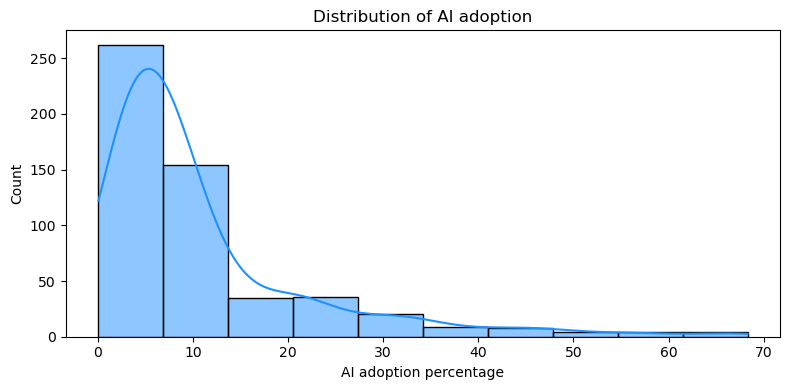

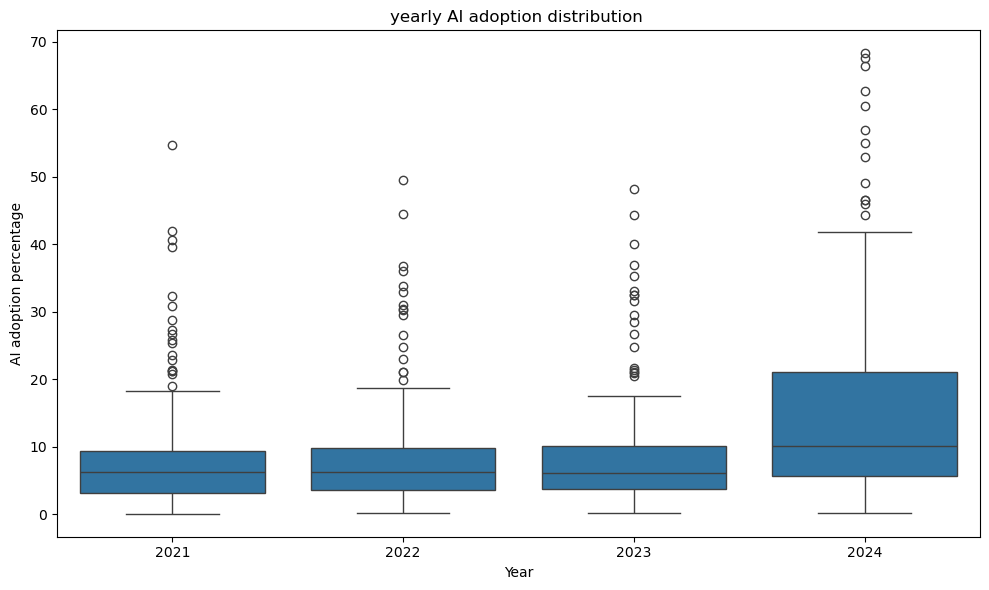

In [3]:
# Descriptive statistics (overall, for all years)
desc = data['ai_adoption'].describe()
print(desc)


# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(data['ai_adoption'], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of AI adoption")
plt.xlabel("AI adoption percentage")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="ai_adoption", data=data)
plt.title("yearly AI adoption distribution ")
plt.xlabel("Year")
plt.ylabel("AI adoption percentage")
plt.tight_layout()
plt.show()

### Enterprises that provided training to develop/upgrade ICT skills

count    536.000000
mean      25.887593
std       18.370186
min        3.030000
25%       13.542500
50%       19.935000
75%       30.857500
max       84.700000
Name: training_ict, dtype: float64


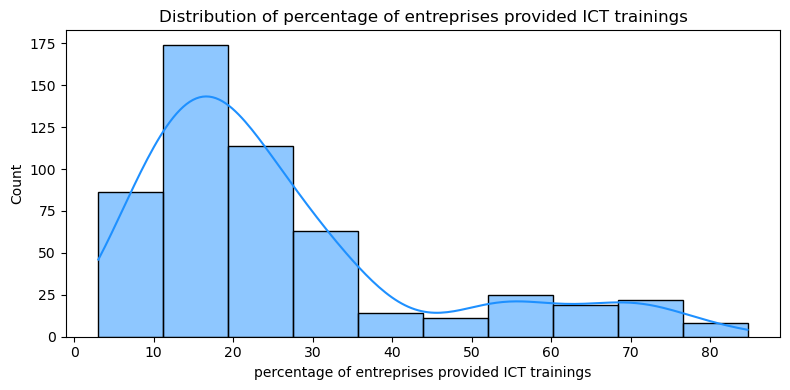

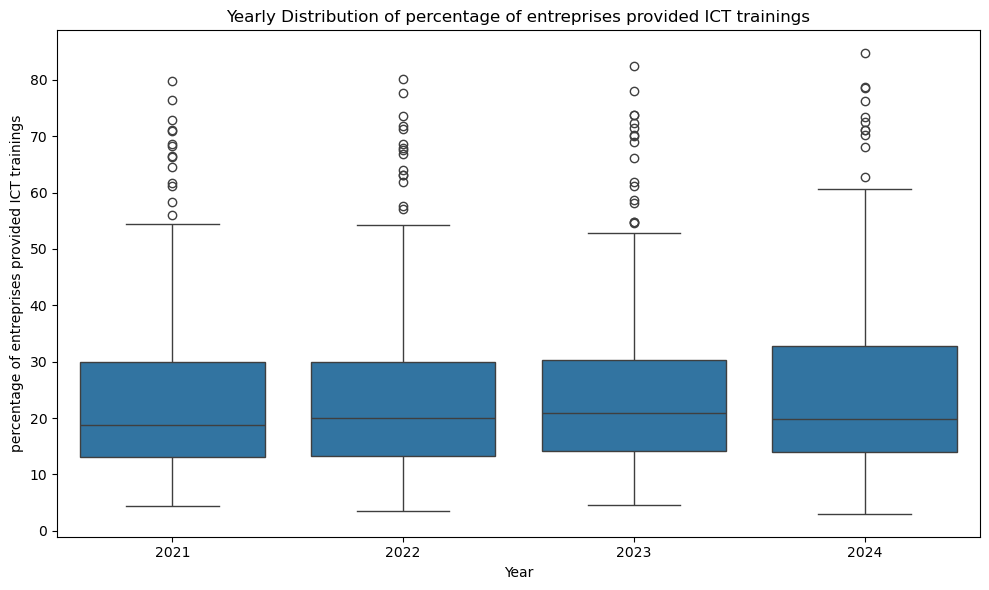

In [8]:
# Descriptive statistics (overall)
desc = data['training_ict'].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(data['training_ict'], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of percentage of entreprises provided ICT trainings")
plt.xlabel("percentage of entreprises provided ICT trainings")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="training_ict", data=data)
plt.title("Yearly Distribution of percentage of entreprises provided ICT trainings")
plt.xlabel("Year")
plt.ylabel("percentage of entreprises provided ICT trainings")
plt.tight_layout()
plt.show()

### Enterprises that employ ICT specialists

count    536.000000
mean      26.589440
std       23.563521
min        1.580000
25%       12.572500
50%       17.605000
75%       28.915000
max       98.250000
Name: spec_ict, dtype: float64


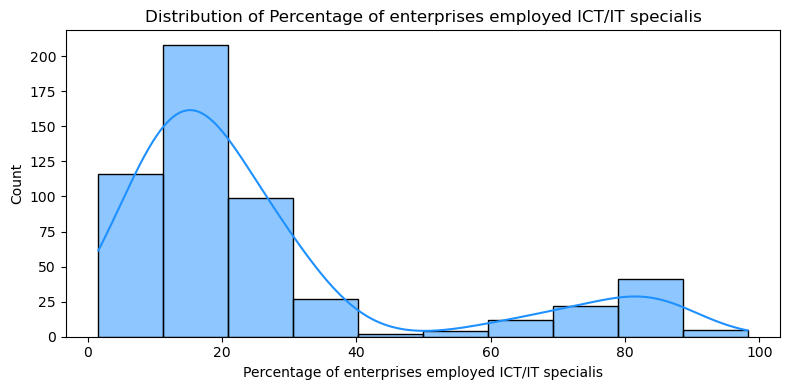

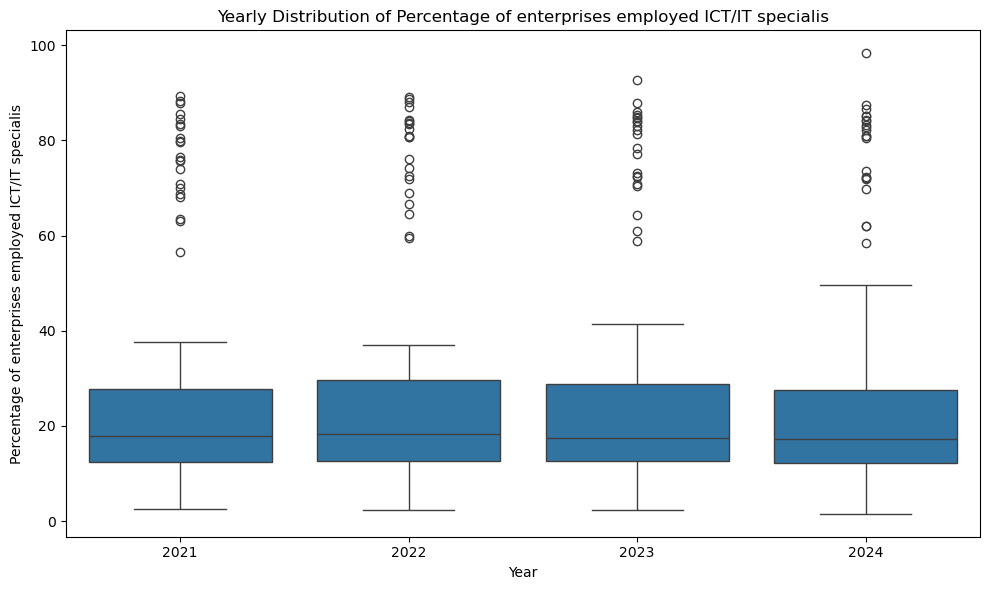

In [9]:
# Descriptive statistics (overall)
desc = data['spec_ict'].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(data['spec_ict'], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of Percentage of enterprises employed ICT/IT specialis")
plt.xlabel("Percentage of enterprises employed ICT/IT specialis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="spec_ict", data=data)
plt.title("Yearly Distribution of Percentage of enterprises employed ICT/IT specialis")
plt.xlabel("Year")
plt.ylabel("Percentage of enterprises employed ICT/IT specialis")
plt.tight_layout()
plt.show()

### Additional variables. Education

count    536.000000
mean      31.059515
std       18.813201
min        4.600000
25%       18.600000
50%       25.250000
75%       34.250000
max       85.500000
Name: tert_edu, dtype: float64


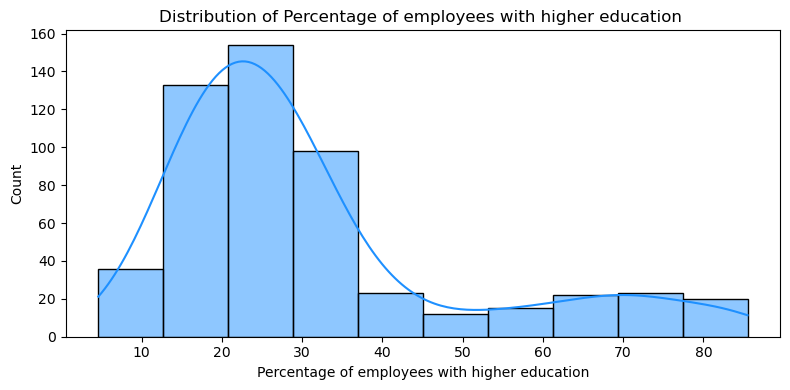

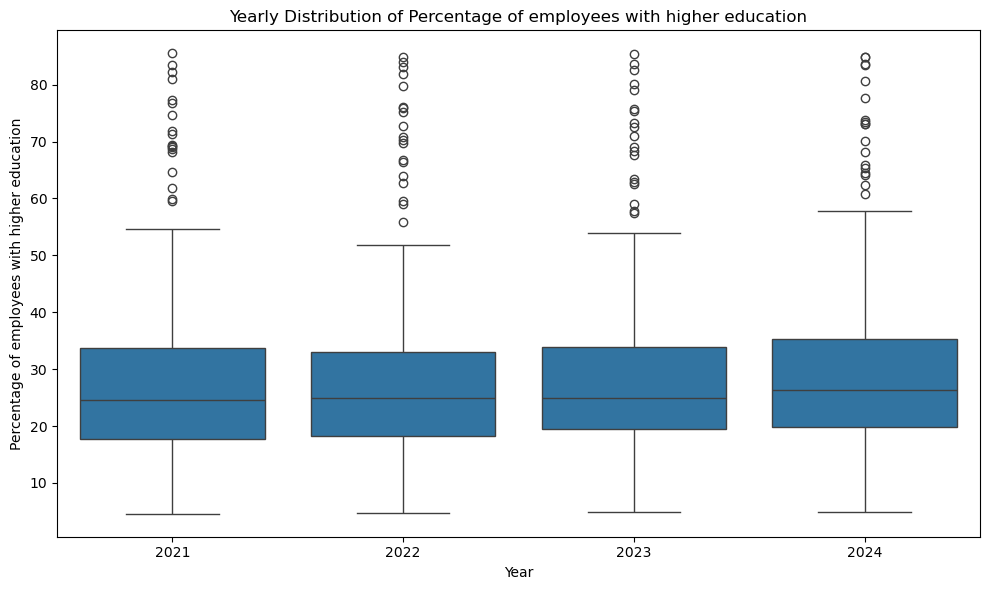

In [10]:
desc = data['tert_edu'].describe()
print(desc)


# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(data['tert_edu'], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of Percentage of employees with higher education ")
plt.xlabel("Percentage of employees with higher education")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y='tert_edu', data=data)
plt.title("Yearly Distribution of Percentage of employees with higher education")
plt.xlabel("Year")
plt.ylabel("Percentage of employees with higher education")
plt.tight_layout()
plt.show()

### Occupation

count    536.000000
mean      36.036847
std       23.817132
min        8.040000
25%       22.240000
50%       27.380000
75%       36.510000
max       96.430000
Name: share_high_skill, dtype: float64


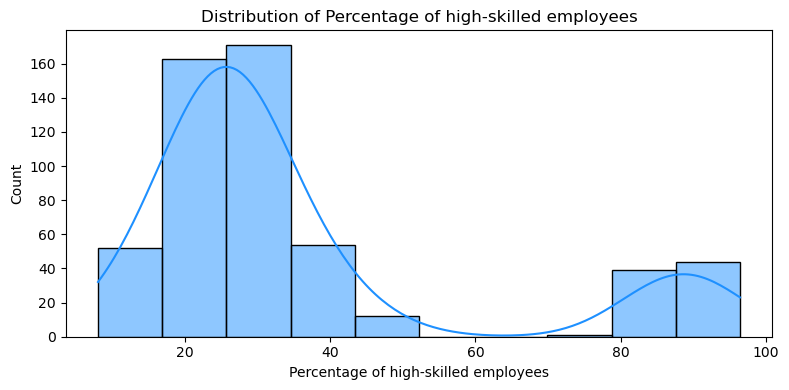

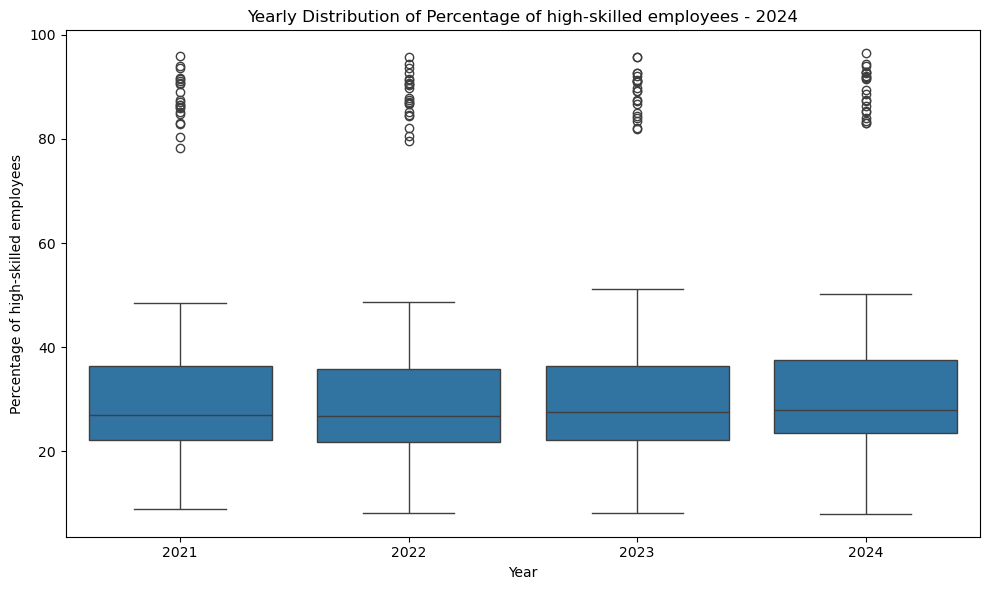

In [11]:
# # Descriptive statistics (overall)
desc = data['share_high_skill'].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(data['share_high_skill'], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of Percentage of high-skilled employees")
plt.xlabel("Percentage of high-skilled employees")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="share_high_skill", data=data)
plt.title("Yearly Distribution of Percentage of high-skilled employees - 2024")
plt.xlabel("Year")
plt.ylabel("Percentage of high-skilled employees")
plt.tight_layout()
plt.show()

### Unemployment rate 


count    536.000000
mean       5.791418
std        2.400008
min        2.200000
25%        4.000000
50%        5.600000
75%        7.100000
max       14.900000
Name: unempl_r, dtype: float64


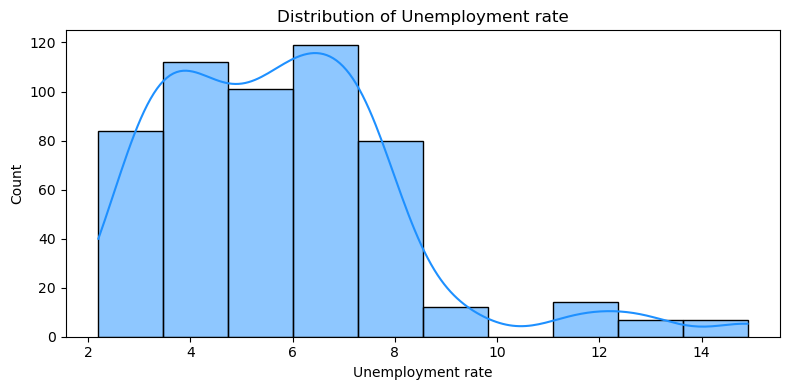

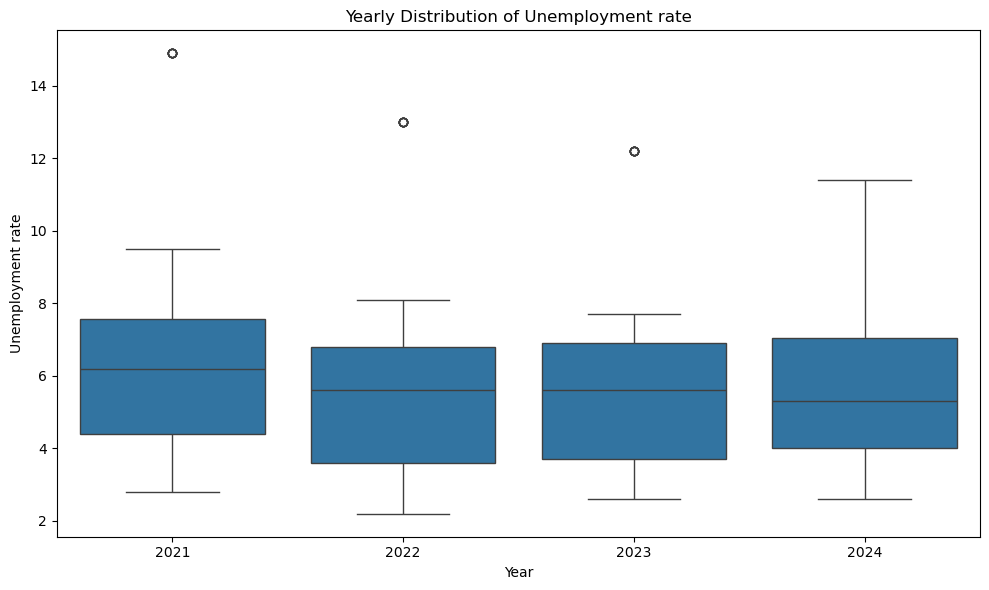

In [12]:
# Descriptive statistics (overall)
desc = data["unempl_r"].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(data["unempl_r"], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of Unemployment rate")
plt.xlabel("Unemployment rate")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="unempl_r", data=data)
plt.title("Yearly Distribution of Unemployment rate")
plt.xlabel("Year")
plt.ylabel("Unemployment rate")
plt.tight_layout()
plt.show()

### Inflation rate 

count    536.000000
mean       5.963060
std        4.280246
min        0.700000
25%        2.700000
50%        4.500000
75%        8.600000
max       19.400000
Name: infl_r, dtype: float64


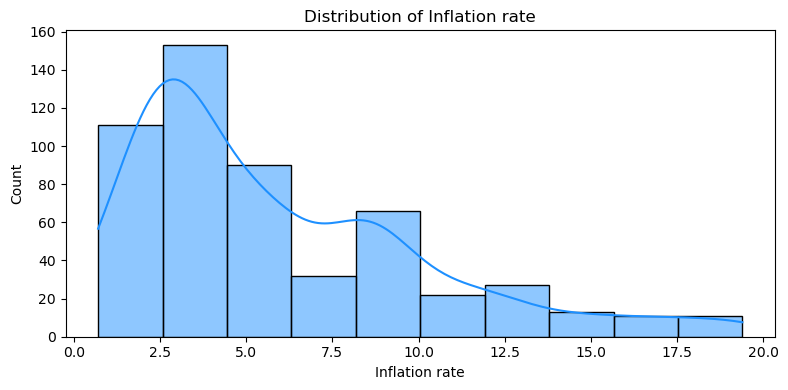

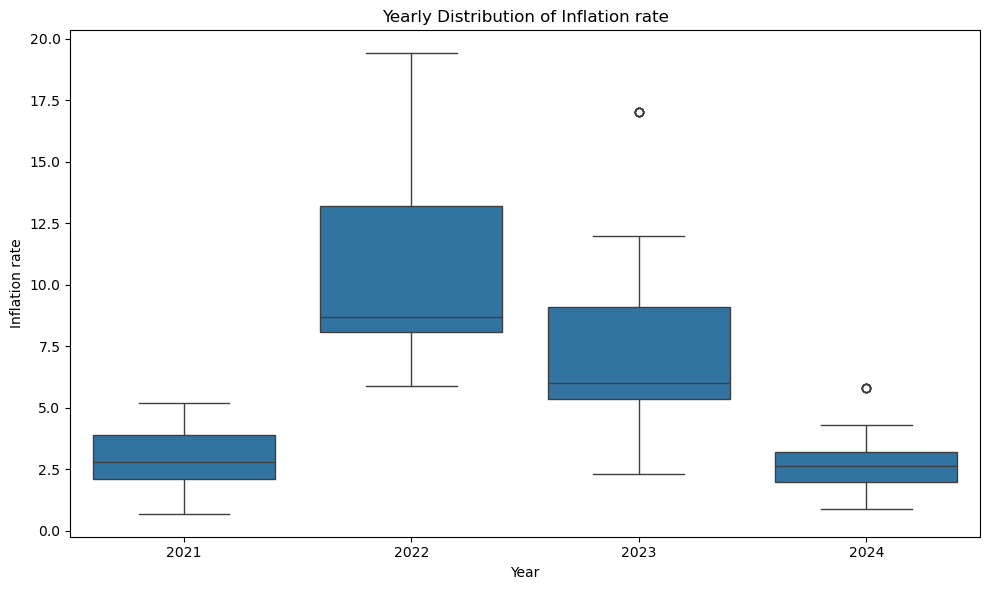

In [13]:
# Descriptive statistics (overall)
desc = data["infl_r"].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(data["infl_r"], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of Inflation rate")
plt.xlabel("Inflation rate")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="infl_r", data=data)
plt.title("Yearly Distribution of Inflation rate")
plt.xlabel("Year")
plt.ylabel("Inflation rate")
plt.tight_layout()
plt.show()

### GDP 

count       536.000000
mean      37223.880597
std       21130.783556
min       10960.000000
25%       21640.000000
50%       30200.000000
75%       48987.500000
max      104510.000000
Name: gdp, dtype: float64


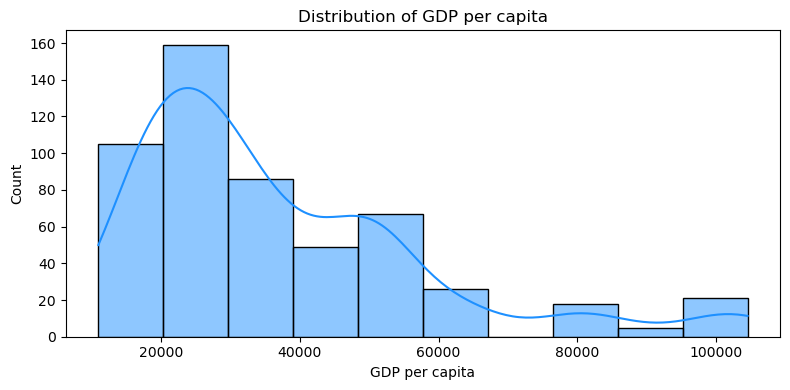

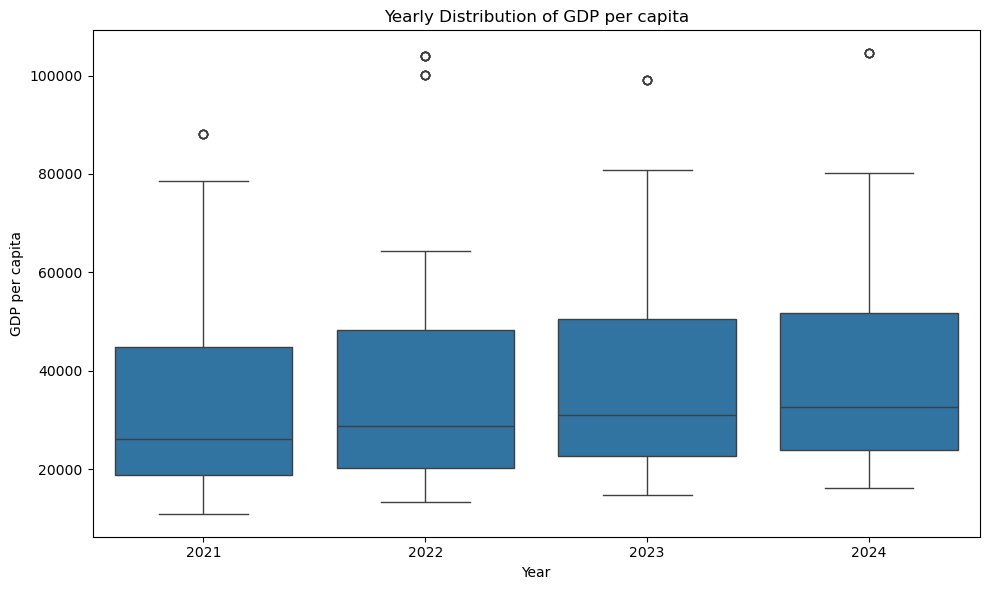

In [14]:
# Descriptive statistics (overall)
desc = data["gdp"].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(data["gdp"], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of GDP per capita")
plt.xlabel("GDP per capita")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="gdp", data=data)
plt.title("Yearly Distribution of GDP per capita")
plt.xlabel("Year")
plt.ylabel("GDP per capita")
plt.tight_layout()
plt.show()

### Productivity 



count    536.000000
mean      70.041063
std       71.949711
min       13.660000
25%       36.947500
50%       52.665000
75%       79.332500
max      665.900000
Name: productivity, dtype: float64


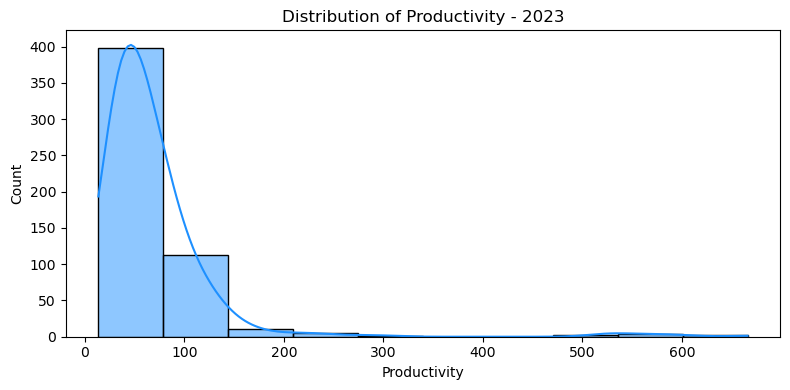

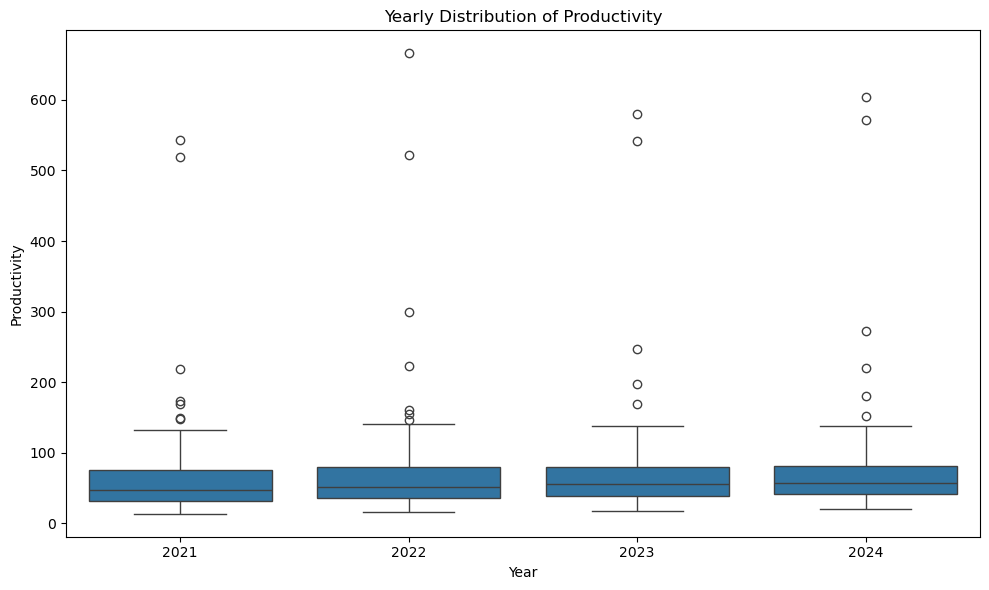

In [15]:
# Descriptive statistics (overall)
desc = data["productivity"].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(data["productivity"], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of Productivity - 2023")
plt.xlabel("Productivity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="productivity", data=data)
plt.title("Yearly Distribution of Productivity")
plt.xlabel("Year")
plt.ylabel("Productivity")
plt.tight_layout()
plt.show()

### Firm size

count    536.000000
mean      32.354646
std       15.464153
min        0.000000
25%       21.557500
50%       32.755000
75%       42.892500
max       66.470000
Name: FSI, dtype: float64


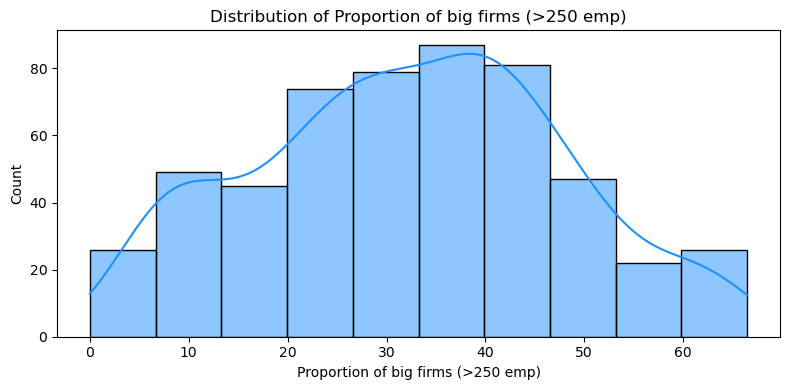

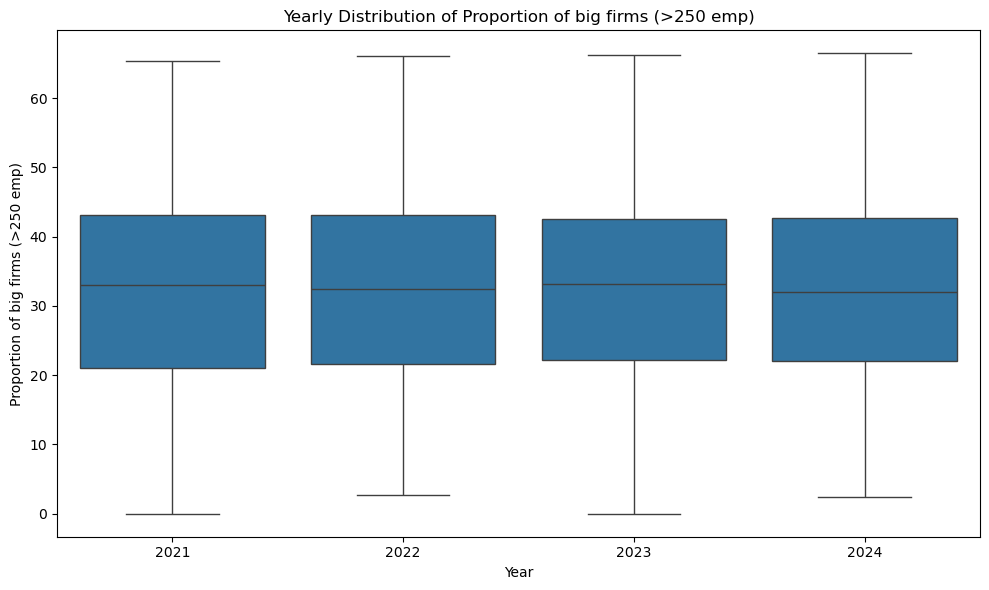

In [16]:
# Descriptive statistics (overall)
desc = data["FSI"].describe()
print(desc)

# Plot distribution for all years
plt.figure(figsize=(8,4))
sns.histplot(data["FSI"], kde=True, bins=10, color='dodgerblue')
plt.title("Distribution of Proportion of big firms (>250 emp)")
plt.xlabel("Proportion of big firms (>250 emp)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional: Distribution by year
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="FSI", data=data)
plt.title("Yearly Distribution of Proportion of big firms (>250 emp)")
plt.xlabel("Year")
plt.ylabel("Proportion of big firms (>250 emp)")
plt.tight_layout()
plt.show()

In [ ]:
print(pd.unique(ict_emp['nace_r2']))

### Matrix

In [ ]:
# Choose variables for the matrix
cols = [
    "log_wage_ij", "educ_ij", "h_skill_ij", "fsi_ij", "unempl_r_i", "infl_r_i", 
    "log_gdp_i", "log_prdct_ij", "ai_ij", "ict_spec_ij", "ict_tr_ij"
]

corr = full_data[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.tight_layout()
plt.show()


### Bar charts !!

In [ ]:
# If multiple sectors per country: average by country
df_country = df_model_ai.groupby('geo', as_index=False)[['wage_ij', 'ai_ij']].mean()

df_country = df_country.sort_values('wage_ij')  # or ai_rate

countries = df_country['geo'].values
wages = df_country['wage_ij'].values
ai = df_country['ai_ij'].values

x = np.arange(len(countries))
width = 0.4

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis: wage bars
bars1 = ax1.bar(x - width/2, wages, width, color='steelblue',
                label='Wage (EUR per hour)')
ax1.set_ylabel('Wage (EUR per hour)')
ax1.set_xticks(x)
ax1.set_xticklabels(countries, rotation=45, ha='right')

# Right axis: AI bars (different scale)
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, ai, width, color='darkorange',
                label='AI adoption (%)')
ax2.set_ylabel('AI adoption (%)')

plt.title('Average wage and AI adoption by country')

# Combined legend
lines = [bars1, bars2]
labels = ['Wage (EUR per hour)', 'AI adoption (%)']
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# If multiple sectors per country: average by country
df_country = df_model_ai.groupby('geo', as_index=False)[['wage_ij', 'ict_tr_ij']].mean()

df_country = df_country.sort_values('wage_ij')  # or ai_rate

countries = df_country['geo'].values
wages = df_country['wage_ij'].values
ict_tr = df_country['ict_tr_ij'].values

x = np.arange(len(countries))
width = 0.4

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis: wage bars
bars1 = ax1.bar(x - width/2, wages, width, color='steelblue',
                label='Wage (EUR per hour)')
ax1.set_ylabel('Wage (EUR per hour)')
ax1.set_xticks(x)
ax1.set_xticklabels(countries, rotation=45, ha='right')

# Right axis: AI bars (different scale)
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, ict_tr, width, color='tan',
                label='ICT training (%)')
ax2.set_ylabel('ICT training (%)')

plt.title('Average wage and ICT training by country')

# Combined legend
lines = [bars1, bars2]
labels = ['Wage (EUR per hour)', 'ICT training (%)']
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
# If multiple sectors per country: average by country
df_country = df_model_ai.groupby('geo', as_index=False)[['wage_ij', 'ict_spec_ij']].mean()

df_country = df_country.sort_values('wage_ij')  # or ai_rate

countries = df_country['geo'].values
wages = df_country['wage_ij'].values
ict_spec = df_country['ict_spec_ij'].values

x = np.arange(len(countries))
width = 0.4

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis: wage bars
bars1 = ax1.bar(x - width/2, wages, width, color='steelblue',
                label='Wage (EUR per hour)')
ax1.set_ylabel('Wage (EUR per hour)')
ax1.set_xticks(x)
ax1.set_xticklabels(countries, rotation=45, ha='right')

# Right axis: AI bars (different scale)
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, ict_spec, width, color='silver',
                label='ICT specialists (%)')
ax2.set_ylabel('ICT specialists (%)')

plt.title('Average wage and ICT specialists by country')

# Combined legend
lines = [bars1, bars2]
labels = ['Wage (EUR per hour)', 'ICT specialists (%)']
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()


## Models 

### Baseline models 

In [73]:
# MODEL 1 dataframe 
from functools import reduce

# List all sector-by-country dataframes for variables in Model 1
dfs_m1 = [wage_2024, educ_2024, prodct_2023, share_high_skill_df, df_fsi_final] 

df_model_1 = reduce(lambda left, right: pd.merge(left, right, on=['geo', 'nace_r2']), dfs_m1)

# Now add macro-level controls (country-only)
df_model_1 = pd.merge(df_model_1, unempl_r_2024, on='geo', how='left')
df_model_1 = pd.merge(df_model_1, infl_r_2024, on='geo', how='left')
df_model_1 = pd.merge(df_model_1, gdp_2024, on='geo', how='left')

print(df_model_1.head())

  geo nace_r2  wage  educ  prodct  share_high_skill        FSI  unempl_r  \
0  AT       C  36.3  35.8   97.68         40.126825  57.515861       5.2   
1  BE       C  38.1  41.0  148.33         41.485958  49.308853       5.7   
2  BG       C   7.9  18.9   23.11         20.620251  36.395969       4.2   
3  CY       C  11.9  36.9   42.75         30.851064  19.474453       4.9   
4  CZ       C  13.4  14.1   43.66         27.347559  45.705806       2.6   

   infl_r      gdp  
0     2.9  53830.0  
1     4.3  52370.0  
2     2.6  16260.0  
3     NaN  35730.0  
4     2.7  29440.0  


In [74]:
duplicates = df_model_1[df_model_1.duplicated(subset=['geo', 'nace_r2'], keep=False)]
print(duplicates)

aggregated = df_model_1.groupby(['geo', 'nace_r2'], as_index=False).agg({
    'wage': 'mean',
    'educ': 'mean',     
    'prodct': 'mean',
    'share_high_skill': 'mean',
    'unempl_r': 'mean',
    'infl_r': 'mean',
    'gdp': 'mean',
    'wage': 'mean',
    'FSI': 'mean'
})

print(aggregated.shape)
print(aggregated.head())

Empty DataFrame
Columns: [geo, nace_r2, wage, educ, prodct, share_high_skill, FSI, unempl_r, infl_r, gdp]
Index: []
(261, 10)
  geo nace_r2  wage  educ  prodct  share_high_skill  unempl_r  infl_r  \
0  AT       C  36.3  35.8   97.68         40.126825       5.2     2.9   
1  AT       F  28.4  24.4   72.19         29.300743       5.2     2.9   
2  AT       G  27.7  22.4   65.77         26.423257       5.2     2.9   
3  AT       H  29.9  23.2   82.22         23.230844       5.2     2.9   
4  AT       J  44.1  66.8   94.04         89.534884       5.2     2.9   

       gdp        FSI  
0  53830.0  57.515861  
1  53830.0  22.051368  
2  53830.0  38.560073  
3  53830.0  45.650485  
4  53830.0  29.231095  


In [75]:
# Add log wage for regression
aggregated['log_wage_ij'] = np.log(aggregated['wage'])
aggregated['log_gdp_i'] = np.log(aggregated['gdp'])
aggregated['log_prdct_ij'] = np.log(aggregated['prodct'])
print(aggregated)

    geo nace_r2  wage  educ  prodct  share_high_skill  unempl_r  infl_r  \
0    AT       C  36.3  35.8   97.68         40.126825       5.2     2.9   
1    AT       F  28.4  24.4   72.19         29.300743       5.2     2.9   
2    AT       G  27.7  22.4   65.77         26.423257       5.2     2.9   
3    AT       H  29.9  23.2   82.22         23.230844       5.2     2.9   
4    AT       J  44.1  66.8   94.04         89.534884       5.2     2.9   
..   ..     ...   ...   ...     ...               ...       ...     ...   
256  SI       Q  20.9  49.7   36.72         64.080100       3.7     NaN   
257  SK       C  13.0  17.4   38.13         25.630178       5.3     3.2   
258  SK       F  11.9  16.1   18.12         24.281884       5.3     3.2   
259  SK       G  12.1  19.8   31.02         23.282083       5.3     3.2   
260  SK       J  21.0  70.1   51.81         85.416667       5.3     3.2   

         gdp        FSI  log_wage_ij  log_gdp_i  log_prdct_ij  
0    53830.0  57.515861     3.59181

In [76]:
aggregated = aggregated.rename(columns={'wage' : 'wage_ij', 'educ' : 'educ_ij','prodct' : 'prodct_ij', 
                                        'share_high_skill' : 'h_skill_ij', 'unempl_r' : 'unempl_r_i', 'infl_r' : 'infl_r_i', 'gdp' : 'gdp_i', 'FSI' : 'fsi_ij'})

print(aggregated)

    geo nace_r2  wage_ij  educ_ij  prodct_ij  h_skill_ij  unempl_r_i  \
0    AT       C     36.3     35.8      97.68   40.126825         5.2   
1    AT       F     28.4     24.4      72.19   29.300743         5.2   
2    AT       G     27.7     22.4      65.77   26.423257         5.2   
3    AT       H     29.9     23.2      82.22   23.230844         5.2   
4    AT       J     44.1     66.8      94.04   89.534884         5.2   
..   ..     ...      ...      ...        ...         ...         ...   
256  SI       Q     20.9     49.7      36.72   64.080100         3.7   
257  SK       C     13.0     17.4      38.13   25.630178         5.3   
258  SK       F     11.9     16.1      18.12   24.281884         5.3   
259  SK       G     12.1     19.8      31.02   23.282083         5.3   
260  SK       J     21.0     70.1      51.81   85.416667         5.3   

     infl_r_i    gdp_i     fsi_ij  log_wage_ij  log_gdp_i  log_prdct_ij  
0         2.9  53830.0  57.515861     3.591818  10.893586    

In [77]:
duplicates = aggregated[aggregated.duplicated()]
print(duplicates)
df_model_1 = aggregated.copy()
# df_model_1 = df_model_1.drop(columns=['wage_ij', 'prodct_ij', 'gdp_i'], axis=1)
df_model_1 = df_model_1.dropna()
print(df_model_1)

Empty DataFrame
Columns: [geo, nace_r2, wage_ij, educ_ij, prodct_ij, h_skill_ij, unempl_r_i, infl_r_i, gdp_i, fsi_ij, log_wage_ij, log_gdp_i, log_prdct_ij]
Index: []
    geo nace_r2  wage_ij  educ_ij  prodct_ij  h_skill_ij  unempl_r_i  \
0    AT       C     36.3     35.8      97.68   40.126825         5.2   
1    AT       F     28.4     24.4      72.19   29.300743         5.2   
2    AT       G     27.7     22.4      65.77   26.423257         5.2   
3    AT       H     29.9     23.2      82.22   23.230844         5.2   
4    AT       J     44.1     66.8      94.04   89.534884         5.2   
..   ..     ...      ...      ...        ...         ...         ...   
247  SE       R     23.2     47.4      27.91   69.990030         8.4   
257  SK       C     13.0     17.4      38.13   25.630178         5.3   
258  SK       F     11.9     16.1      18.12   24.281884         5.3   
259  SK       G     12.1     19.8      31.02   23.282083         5.3   
260  SK       J     21.0     70.1      51.

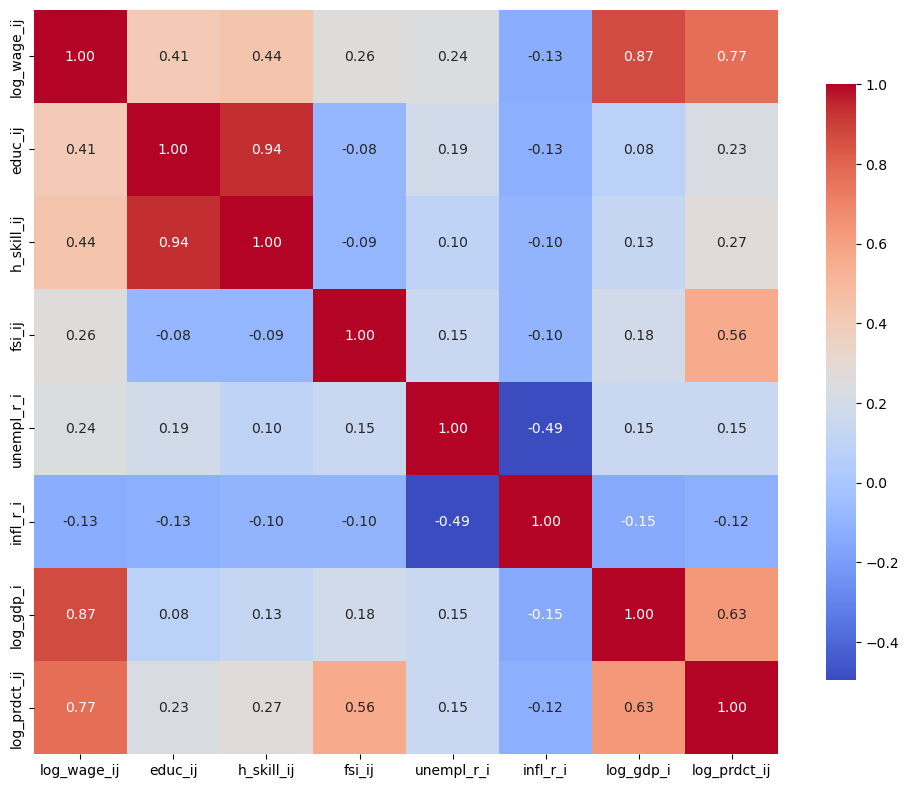

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Choose variables for the matrix
cols = [
    "log_wage_ij", "educ_ij", "h_skill_ij",
    "fsi_ij", "unempl_r_i", "infl_r_i", "log_gdp_i", "log_prdct_ij"
]

corr = df_model_1[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.tight_layout()
plt.show()
